# AG2 - Actividad Guiada 2
## 03MIAR - Algoritmos de Optimización

**Nombre:** Donald Silva

**Link:** `https://colab.research.google.com/drive/17Vg5oyxlWnt0UK2v4HosHmxIJSboO-PK?usp=sharing`

**Github:** `https://github.com/dsilvas2001/03MIAR_DonaldSilva_AG_.git`

---

### Objetivos de la actividad

1. Desarrollar algoritmos con la técnica de **programación dinámica** para resolver problemas.
2. Desarrollar algoritmos con la técnica de **ramificación y poda** para resolver problemas.
3. Desarrollar algoritmos con la técnica del **descenso del gradiente**.

### Contenido

| Apartado | Técnica | Problema |
|---|---|---|
| 1 | Programación dinámica | Viaje por el río |
| 2 | Ramificación y poda | Asignación de tareas |
| 3 | Descenso del gradiente | Paraboloide $x^2+y^2$ y la función propuesta |

### Cómo se verifica este notebook

Cada apartado termina contrastando el algoritmo desarrollado con una **referencia independiente**
—una búsqueda exhaustiva, o derivadas numéricas en el caso del gradiente— mediante `assert`. Si el
notebook se ejecuta entero sin lanzar ninguna excepción, los algoritmos son correctos.

Está pensado para ejecutarse de arriba abajo: *Entorno de ejecución → Ejecutar todo*.

In [1]:
# Utilidades comunes
import heapq
import itertools
import math
import random
import time
from itertools import permutations
# instalar sympy
%pip install sympy

random.seed(42)   # Semilla fija: los experimentos son reproducibles

print("Python", __import__("sys").version.split()[0])

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Python 3.14.5



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
# 1. Programación dinámica: viaje por el río

**Definición.** Se divide el problema en subproblemas más pequeños y se **guardan** sus soluciones
para reutilizarlas, en lugar de recalcularlas.

**Características que identifican un problema aplicable:**

- Se pueden almacenar las soluciones de los subproblemas para usarlas más adelante.
- Debe cumplirse el **principio de optimalidad de Bellman**: *en una secuencia óptima de
  decisiones, toda subsecuencia también es óptima*.
- Guardar las soluciones parciales obliga a vigilar la **complejidad espacial**, no solo la temporal.

### El problema

En un río hay **n** embarcaderos y hay que desplazarse río abajo de uno a otro. Cada embarcadero
tiene precios distintos para ir a otro situado más abajo. Para ir del embarcadero $i$ al $j$ puede
salir más barato **hacer trasbordo** en un embarcadero intermedio $k$. Se trata de determinar la
combinación más barata.

### Por qué cumple el principio de Bellman

Si la ruta más barata de $i$ a $j$ pasa por $k$, entonces el tramo de $i$ a $k$ que contiene es
forzosamente el más barato posible entre $i$ y $k$: si existiera otro más barato, sustituyéndolo
obtendríamos una ruta de $i$ a $j$ mejor que la óptima, lo cual es contradictorio. Esa es
exactamente la propiedad que permite construir la solución a partir de las de los subproblemas:

$$\text{PRECIOS}[i][j] = \min\Big( \text{TARIFAS}[i][j],\ \min_{i < k < j} \big( \text{PRECIOS}[i][k] + \text{TARIFAS}[k][j] \big) \Big)$$

Como solo se navega aguas abajo, el grafo es acíclico y basta rellenar la matriz triangular
superior resolviendo, para cada origen, los destinos en orden creciente.

In [2]:
"""Si no es posible ir de i a j se usa un valor que garantice que ese trayecto nunca se elige.
 Se emplea math.inf en TODA la matriz en lugar de un número grande como 999: sumar dos
 centinelas finitos (999 + 999 = 1998) da un valor que ya no se reconoce como "inalcanzable",
 mientras que inf + inf sigue siendo inf."""
INF = math.inf

#          hacia:  0    1    2    3    4    5    6
TARIFAS = [
    [        0,   5,   4,   3, INF, INF, INF],   # desde el embarcadero 0
    [      INF,   0, INF,   2,   3, INF,  11],   # desde el 1
    [      INF, INF,   0,   1, INF,   4,  10],   # desde el 2
    [      INF, INF, INF,   0,   5,   6,   9],   # desde el 3
    [      INF, INF, INF, INF,   0, INF,   4],   # desde el 4
    [      INF, INF, INF, INF, INF,   0,   3],   # desde el 5
    [      INF, INF, INF, INF, INF, INF,   0],   # desde el 6
]

N_EMBARCADEROS = len(TARIFAS)

In [3]:
def precios_minimos(tarifas):
    """Coste mínimo entre cada par de embarcaderos i <= j, y trayecto asociado.

    Devuelve (precios, ruta):
      - precios[i][j] = coste mínimo de ir de i a j (inf si no hay trayecto posible).
      - ruta[i][j]    = embarcadero ANTERIOR a j en el trayecto óptimo que parte de i.

    Guardar el predecesor, y no un nodo intermedio cualquiera, es lo que convierte la
    reconstrucción del trayecto en un simple bucle hacia atrás.
    """
    n = len(tarifas)
    precios = [[INF] * n for _ in range(n)]
    ruta = [[None] * n for _ in range(n)]

    # Ir de i a i cuesta 0. Sin esta inicialización la diagonal queda a infinito.
    for i in range(n):
        precios[i][i] = 0
        ruta[i][i] = i

    for i in range(n):
        for j in range(i + 1, n):
            mejor = tarifas[i][j]      # Coste de ir directamente, sin trasbordos
            anterior = i               # ...y entonces el embarcadero previo a j es el propio i

            # Se prueban todos los trasbordos intermedios posibles. Cuando se necesita
            # precios[i][k] con k < j, ya está calculado: por eso j crece de uno en uno.
            for k in range(i + 1, j):
                candidato = precios[i][k] + tarifas[k][j]
                if candidato < mejor:
                    mejor = candidato
                    anterior = k

            precios[i][j] = mejor
            ruta[i][j] = anterior if mejor < INF else None

    return precios, ruta


def reconstruir_ruta(ruta, desde, hasta):
    # Trayecto óptimo completo, con origen Y destino incluidos. Lista vacía si no existe.
    if ruta[desde][hasta] is None:
        return []

    camino = [hasta]
    while hasta != desde:
        hasta = ruta[desde][hasta]
        camino.append(hasta)

    return camino[::-1]


def coste_camino(tarifas, camino):
    # Suma las tarifas de los tramos consecutivos de un trayecto.
    return sum(tarifas[a][b] for a, b in zip(camino, camino[1:]))


PRECIOS, RUTA = precios_minimos(TARIFAS)

In [4]:
def imprime_matriz(matriz, titulo, ancho=6):
    # Imprime una matriz con cabecera de índices; lo inalcanzable como '-'.
    n = len(matriz)
    print(titulo)
    print("      " + "".join(f"{j:>{ancho}}" for j in range(n)))
    for i, fila in enumerate(matriz):
        celdas = "".join(f"{('-' if v is None or v == INF else v):>{ancho}}" for v in fila)
        print(f"{i:>4}  {celdas}")
    print()


imprime_matriz(PRECIOS, "PRECIOS[i][j] = coste mínimo de ir del embarcadero i al j")
imprime_matriz(RUTA, "RUTA[i][j] = embarcadero anterior a j en el trayecto óptimo desde i")

print("Trayectos óptimos desde el embarcadero 0:")
for destino in range(1, N_EMBARCADEROS):
    camino = reconstruir_ruta(RUTA, 0, destino)
    directo = TARIFAS[0][destino]
    texto = "sin tramo directo" if directo == INF else f"directo: {directo}"
    trayecto = " -> ".join(str(x) for x in camino)
    print(f"   0 -> {destino}: coste {PRECIOS[0][destino]:>3}   ruta {trayecto:<20} ({texto})")

PRECIOS[i][j] = coste mínimo de ir del embarcadero i al j
           0     1     2     3     4     5     6
   0       0     5     4     3     8     8    11
   1       -     0     -     2     3     8     7
   2       -     -     0     1     6     4     7
   3       -     -     -     0     5     6     9
   4       -     -     -     -     0     -     4
   5       -     -     -     -     -     0     3
   6       -     -     -     -     -     -     0

RUTA[i][j] = embarcadero anterior a j en el trayecto óptimo desde i
           0     1     2     3     4     5     6
   0       0     0     0     0     1     2     5
   1       -     1     -     1     1     3     4
   2       -     -     2     2     3     2     5
   3       -     -     -     3     3     3     3
   4       -     -     -     -     4     -     4
   5       -     -     -     -     -     5     5
   6       -     -     -     -     -     -     6

Trayectos óptimos desde el embarcadero 0:
   0 -> 1: coste   5   ruta 0 -> 1            

In [4]:
# --- Verificación contra una búsqueda exhaustiva -----------------------------------------------

def mejor_ruta_fuerza_bruta(tarifas, desde, hasta):
    """Referencia independiente: explora TODOS los trayectos aguas abajo entre desde y hasta."""
    n = len(tarifas)
    mejor_coste, mejor_camino = INF, []

    def explora(actual, coste, camino):
        nonlocal mejor_coste, mejor_camino
        if actual == hasta:
            if coste < mejor_coste:
                mejor_coste, mejor_camino = coste, list(camino)
            return
        for siguiente in range(actual + 1, n):
            if tarifas[actual][siguiente] < INF:      # Solo por los tramos que existen
                camino.append(siguiente)
                explora(siguiente, coste + tarifas[actual][siguiente], camino)
                camino.pop()

    explora(desde, 0, [desde])
    return mejor_coste, mejor_camino


# El caso del enunciado: de 0 a 6 no hay tramo directo, y trasbordar en 2 y en 5 cuesta 4+4+3
assert PRECIOS[0][6] == 11, f"Se esperaba 11 y se ha obtenido {PRECIOS[0][6]}"
assert reconstruir_ruta(RUTA, 0, 6) == [0, 2, 5, 6]
assert coste_camino(TARIFAS, [0, 2, 5, 6]) == 11
assert PRECIOS[6][6] == 0, "La diagonal debe valer 0 en todas las filas"

comprobados = 0
for desde in range(N_EMBARCADEROS):
    for hasta in range(desde, N_EMBARCADEROS):
        coste_bruto, _ = mejor_ruta_fuerza_bruta(TARIFAS, desde, hasta)

        if coste_bruto == INF:
            assert PRECIOS[desde][hasta] == INF, f"{desde}->{hasta} no debería tener ruta"
            assert reconstruir_ruta(RUTA, desde, hasta) == []
        else:
            assert PRECIOS[desde][hasta] == coste_bruto, f"{desde}->{hasta}: coste incorrecto"
            camino = reconstruir_ruta(RUTA, desde, hasta)
            assert camino[0] == desde and camino[-1] == hasta
            assert coste_camino(TARIFAS, camino) == coste_bruto, f"{desde}->{hasta}: ruta incoherente"

        comprobados += 1

print(f"Verificado: los {comprobados} pares coinciden con la búsqueda exhaustiva, y cada")
print("trayecto reconstruido cuesta exactamente lo que anuncia la tabla PRECIOS.")

Verificado: los 28 pares coinciden con la búsqueda exhaustiva, y cada
trayecto reconstruido cuesta exactamente lo que anuncia la tabla PRECIOS.


### Complejidad

Tres bucles anidados sobre los $n$ embarcaderos:

- **Tiempo:** $O(n^3)$
- **Espacio:** $O(n^2)$, las dos matrices

La búsqueda exhaustiva usada como control explora todos los caminos aguas abajo entre los extremos,
que son $2^{\,n-2}$: exponencial. Con $n=7$ da lo mismo, pero esa distancia entre $O(n^3)$ y
$O(2^n)$ es justamente lo que aporta la programación dinámica, y el motivo de guardar las
soluciones parciales aunque cueste memoria.

> **Tres decisiones de diseño**, por si se comparan con otras implementaciones del mismo problema:
>
> 1. **La diagonal se inicializa a 0.** Es lo que hace que `precios[i][i]` valga 0 y no infinito, y
>    da el caso base de la recurrencia.
> 2. **`math.inf` en toda la matriz**, en vez de mezclar `inf` con un 999. Con centinelas finitos,
>    `999 + 999 = 1998` deja de reconocerse como «inalcanzable» en cuanto las tarifas crecen.
> 3. **`RUTA[i][j]` guarda el predecesor de `j`**, no un nodo intermedio cualquiera. Así
>    `reconstruir_ruta` es un bucle de tres líneas que devuelve la lista completa `[0, 2, 5, 6]`,
>    **incluido el destino**, en lugar de una cadena a la que hay que rematar después.

---
# 2. Ramificación y poda: asignación de tareas

Hay $n$ agentes y $n$ tareas. Asignar la tarea $j$ al agente $i$ cuesta `COSTES[i][j]`. Cada agente
recibe exactamente una tarea y cada tarea la hace exactamente un agente. Se busca la asignación de
**coste total mínimo**.

### La técnica

Ramificación y poda recorre el mismo árbol de soluciones parciales que la vuelta atrás, pero con
dos diferencias que lo cambian todo:

1. **Ramificar.** Cada nodo es una asignación parcial y se expande generando un hijo por cada tarea
   todavía libre.
2. **Acotar.** De cada nodo se calcula una **cota inferior**: lo mínimo que podría llegar a costar
   cualquier solución completa que salga de él.
3. **Podar.** Si la cota inferior de un nodo ya iguala o supera el coste de la mejor solución
   encontrada, ese nodo no puede contener nada mejor y se descarta entero, sin explorarlo.
4. **Elegir el nodo más prometedor.** En vez de bajar en profundidad como la vuelta atrás, se
   mantiene un conjunto de **nodos vivos** y se expande siempre el de menor cota inferior. Encontrar
   pronto una solución buena hace que la poda sea mucho más agresiva después.

### La condición que hay que respetar

> **La cota inferior nunca puede sobreestimar el coste real de completar el nodo.**

Es el único requisito para que la poda sea segura. Si una cota se pasa de optimista por arriba, el
algoritmo descarta ramas que sí contenían el óptimo y **devuelve una solución equivocada**, no solo
tarda más. Por eso la cota de aquí abajo estima cada agente pendiente con el mínimo sobre las tareas
**que realmente quedan libres**.

**Representación.** `S[i]` es la tarea asignada al agente `i`. Una asignación parcial es una tupla
de longitud $k$: los agentes $0 \ldots k-1$ ya están asignados y faltan los demás.

In [5]:
#    T A R E A
#   A
#   G          COSTES[agente][tarea]
#   E
#   N
#   T
#   E
COSTES = [
    [11, 12, 18, 40],
    [14, 15, 13, 22],
    [11, 17, 19, 23],
    [17, 14, 20, 28],
]


def coste(S, costes):
    # Coste de una asignación, parcial o completa. S[i] = tarea del agente i.
    return sum(costes[agente][tarea] for agente, tarea in enumerate(S))


def cota_inferior(S, costes):
    """Lo mínimo que puede llegar a costar cualquier solución que complete S.

    Es el coste ya comprometido más, por cada agente pendiente, la más barata de las tareas
    TODAVÍA LIBRES. Se relaja la restricción de que dos agentes no puedan coger la misma
    tarea, así que el valor obtenido nunca supera al coste real de completar: la cota es
    válida y podar con ella es seguro.
    """
    n = len(costes)
    libres = [t for t in range(n) if t not in S]
    total = coste(S, costes)

    for agente in range(len(S), n):
        total += min(costes[agente][t] for t in libres)

    return total


def solucion_voraz(S, costes):
    """Completa S dando a cada agente pendiente la tarea libre más barata para él.

    Devuelve una asignación completa y factible. Sirve como cota superior inicial: cuanto
    mejor sea, antes empieza a podar el algoritmo.
    """
    n = len(costes)
    libres = [t for t in range(n) if t not in S]
    solucion = list(S)

    for agente in range(len(S), n):
        elegida = min(libres, key=lambda t: costes[agente][t])
        solucion.append(elegida)
        libres.remove(elegida)

    return tuple(solucion)


def crear_hijos(S, n):
    """Ramificación: asigna al siguiente agente cada una de las tareas libres.

    (0,) -> (0,1), (0,2), (0,3)
    """
    return [S + (t,) for t in range(n) if t not in S]


print("Asignación parcial (0,2): el agente 0 hace la tarea 0 y el agente 1 la tarea 2")
print("   coste comprometido :", coste((0, 2), COSTES))
print("   cota inferior      :", cota_inferior((0, 2), COSTES))
print("   hijos              :", crear_hijos((0, 2), 4))
print()
print("Solución voraz inicial:", solucion_voraz((), COSTES),
      "con coste", coste(solucion_voraz((), COSTES), COSTES))

Asignación parcial (0,2): el agente 0 hace la tarea 0 y el agente 1 la tarea 2
   coste comprometido : 24
   cota inferior      : 55
   hijos              : [(0, 2, 1), (0, 2, 3)]

Solución voraz inicial: (0, 2, 1, 3) con coste 69


In [6]:
def ramificacion_y_poda(costes):
    """Asignación de coste mínimo por ramificación y poda.

    Estrategia del nodo más prometedor: los nodos vivos se guardan en un montículo
    ordenado por cota inferior, de modo que siempre se expande el que menos promete costar.

    Devuelve (solucion, coste, nodos_expandidos, nodos_podados).
    """
    n = len(costes)

    """ Cota superior inicial: una solución factible cualquiera. Sin esto habría que
     esperar a llegar a la primera hoja para poder podar algo. """
    mejor_solucion = solucion_voraz((), costes)
    mejor_coste = coste(mejor_solucion, costes)

    """ El contador desempata cuando dos nodos tienen la misma cota, para que el montículo
     no tenga que comparar las tuplas de asignación entre sí."""
    contador = itertools.count()
    vivos = [(cota_inferior((), costes), next(contador), ())]

    expandidos = podados = 0

    while vivos:
        ci, _, S = heapq.heappop(vivos)

        # El nodo pudo entrar cuando la mejor solución era peor: se repoda al sacarlo.
        if ci >= mejor_coste:
            podados += 1
            continue

        expandidos += 1

        for hijo in crear_hijos(S, n):
            if len(hijo) == n:
                # Solución completa: aquí la cota inferior ya ES el coste exacto
                coste_hijo = coste(hijo, costes)
                if coste_hijo < mejor_coste:
                    mejor_coste, mejor_solucion = coste_hijo, hijo
            else:
                ci_hijo = cota_inferior(hijo, costes)
                if ci_hijo < mejor_coste:
                    heapq.heappush(vivos, (ci_hijo, next(contador), hijo))
                else:
                    podados += 1        # Poda: por esta rama no puede haber nada mejor

    return mejor_solucion, mejor_coste, expandidos, podados


solucion, coste_optimo, expandidos, podados = ramificacion_y_poda(COSTES)

print("Solución óptima:", solucion, " coste:", coste_optimo)
for agente, tarea in enumerate(solucion):
    print(f"   agente {agente} -> tarea {tarea}   ({COSTES[agente][tarea]})")
print(f"\nNodos expandidos: {expandidos}   |   nodos podados: {podados}")

Solución óptima: (0, 2, 3, 1)  coste: 61
   agente 0 -> tarea 0   (11)
   agente 1 -> tarea 2   (13)
   agente 2 -> tarea 3   (23)
   agente 3 -> tarea 1   (14)

Nodos expandidos: 7   |   nodos podados: 11


In [7]:
# --- Verificación contra la búsqueda exhaustiva ------------------------------------------------

def asignacion_fuerza_bruta(costes):
    # Referencia independiente: prueba las n! asignaciones posibles.
    n = len(costes)
    return min(((p, coste(p, costes)) for p in permutations(range(n))), key=lambda t: t[1])


mejor_bruta, coste_bruto = asignacion_fuerza_bruta(COSTES)
print("Fuerza bruta sobre las 4! = 24 permutaciones:", mejor_bruta, "con coste", coste_bruto)

assert coste_optimo == coste_bruto, f"{coste_optimo} != {coste_bruto}"
assert sorted(solucion) == list(range(len(COSTES))), "no es una asignación válida"
assert coste_optimo == 61 and solucion == (0, 2, 3, 1)

""" La cota inferior nunca puede pasarse: para cualquier asignación parcial debe quedar por
 debajo del coste de la mejor solución completa que la extiende. Si esto fallara, la poda
 estaría descartando ramas buenas."""
n = len(COSTES)
for k in range(n + 1):
    for parcial in permutations(range(n), k):
        completas = [p for p in permutations(range(n)) if p[:k] == parcial]
        mejor_real = min(coste(p, COSTES) for p in completas)
        assert cota_inferior(parcial, COSTES) <= mejor_real, f"cota inválida en {parcial}"

# Y el algoritmo completo, contra fuerza bruta en instancias aleatorias
random.seed(11)
for _ in range(200):
    tam = random.randint(2, 7)
    matriz = [[random.randint(1, 60) for _ in range(tam)] for _ in range(tam)]
    _, c, _, _ = ramificacion_y_poda(matriz)
    assert c == asignacion_fuerza_bruta(matriz)[1], f"discrepancia con {matriz}"

print("\nVerificado: la cota inferior nunca sobreestima en ninguna de las asignaciones")
print("parciales posibles, y el algoritmo coincide con la fuerza bruta en 200 instancias")
print("aleatorias de tamaño 2x2 a 7x7.")

Fuerza bruta sobre las 4! = 24 permutaciones: (0, 2, 3, 1) con coste 61

Verificado: la cota inferior nunca sobreestima en ninguna de las asignaciones
parciales posibles, y el algoritmo coincide con la fuerza bruta en 200 instancias
aleatorias de tamaño 2x2 a 7x7.


In [8]:
# ¿Cuánto ha podado en el caso del enunciado?
print(f"Asignaciones posibles (4!) : {math.factorial(4)}")
print(f"Nodos expandidos           : {expandidos}")
print(f"Nodos podados              : {podados}")
print(f"Coste óptimo               : {coste_optimo}  con la asignación {solucion}")

Asignaciones posibles (4!) : 24
Nodos expandidos           : 7
Nodos podados              : 11
Coste óptimo               : 61  con la asignación (0, 2, 3, 1)


### Complejidad

En el peor caso, cuando la cota no consigue podar nada, se recorren las $n!$ asignaciones:
$O(n!)$. La poda no cambia esa cota superior teórica, pero sí el comportamiento real: en la matriz
4×4 del enunciado basta con **expandir 7 nodos**, descartando otros 11 sin llegar a explorarlos,
frente a las 24 asignaciones que habría que revisar una por una.

El coste de cada nodo es $O(n^2)$ por el cálculo de la cota inferior, y el espacio depende de
cuántos nodos vivos lleguen a coexistir en el montículo.

> **Nota sobre la cota inferior.** Es la pieza delicada de la técnica, y conviene detallar por qué
> la de arriba es válida. Al estimar cada agente pendiente con el mínimo sobre las tareas **libres**,
> se está resolviendo un problema relajado se permite que dos agentes cojan la misma tarea, y la
> solución de un problema relajado nunca cuesta más que la del original. Por eso la estimación se
> queda siempre por debajo, cosa que la celda de verificación comprueba sobre **todas** las
> asignaciones parciales posibles.
>
> Una variante habitual es estimar el tramo pendiente recorriendo las últimas posiciones de la
> matriz, dando por hecho que las tareas libres son siempre las de índice más alto. No lo son: si
> los agentes 0 y 1 han recibido las tareas 1 y 3, las libres son la 0 y la 2, no la 2 y la 3. Con
> esa estimación la cota puede quedar por encima del coste real, y entonces la poda descarta ramas
> que contenían el óptimo: en esta misma matriz la búsqueda termina en la asignación $(1,2,0,3)$ con
> coste **64**, cuando el óptimo es **61**.

---
# 3. Descenso del gradiente

Las dos técnicas anteriores buscan sobre un conjunto **discreto** de soluciones. El descenso del
gradiente resuelve un problema distinto: minimizar una función **continua y derivable**.

La idea es que el gradiente $\nabla f$ apunta en la dirección de **máximo crecimiento** de la
función. Para minimizar basta con avanzar en sentido contrario, un paso cada vez:

$$P_{k+1} = P_k - \eta \cdot \nabla f(P_k)$$

donde $\eta$ es la **tasa de aprendizaje**. Es el parámetro delicado:

- Demasiado pequeña, la convergencia es lentísima y puede quedarse a medio camino.
- Demasiado grande, el paso se pasa de largo y la búsqueda oscila o diverge.

Y una limitación de fondo: el método es **local**. Solo ve la pendiente bajo sus pies, así que cae
al mínimo más cercano al punto de partida, que no tiene por qué ser el mínimo global.

In [9]:
import matplotlib.pyplot as plt   # Generación de gráficos
import numpy as np                # Tratamiento de matrices N-dimensionales


def descenso_gradiente(f, df, punto_inicial, tasa=0.1, iteraciones=50, limites=None,
                       decaimiento=1.0):
    """Descenso del gradiente. Devuelve (punto_final, trayectoria).

    En cada paso se avanza en sentido contrario al gradiente, que es la dirección de
    máximo crecimiento.

    `limites` es una lista de pares (mínimo, máximo) por coordenada. Sirve para mantener la
    búsqueda dentro de la región de interés en funciones cuyo gradiente se dispara fuera de
    ella, como la del apartado 3.2.

    `decaimiento` multiplica la tasa de aprendizaje en cada iteración. Con 1.0 la tasa es
    fija; con un valor algo menor que 1 se va reduciendo a medida que nos acercamos al
    mínimo, que es lo que permite asentarse en lugar de oscilar a su alrededor.
    """
    P = list(punto_inicial)
    trayectoria = [tuple(P)]
    tasa_actual = tasa

    for _ in range(iteraciones):
        gradiente = df(P)
        P = [P[i] - tasa_actual * gradiente[i] for i in range(len(P))]

        if limites is not None:
            P = [min(max(P[i], limites[i][0]), limites[i][1]) for i in range(len(P))]

        trayectoria.append(tuple(P))
        tasa_actual *= decaimiento     # Paso cada vez más corto

    return P, trayectoria


def gradiente_numerico(f, P, h=1e-6):
    # Gradiente por diferencias finitas centradas. Sirve para validar el gradiente analítico.
    derivadas = []
    for i in range(len(P)):
        adelante, atras = list(P), list(P)
        adelante[i] += h
        atras[i] -= h
        derivadas.append((f(adelante) - f(atras)) / (2 * h))
    return derivadas

## 3.1 Un caso conocido: el paraboloide

$$f(x,y) = x^2 + y^2$$

El mínimo está obviamente en $(0,0)$, y precisamente por eso sirve para comprobar que el método
llega donde debe. Su gradiente es inmediato:

$$\nabla f = \left( \frac{\partial f}{\partial x},\ \frac{\partial f}{\partial y} \right) = (2x,\ 2y)$$

In [10]:
# Paraboloide
f_paraboloide = lambda X: X[0] ** 2 + X[1] ** 2      # Función
df_paraboloide = lambda X: [2 * X[0], 2 * X[1]]      # Gradiente

print("f(1,2)  =", f_paraboloide([1, 2]))
print("df(1,2) =", df_paraboloide([1, 2]))

# El gradiente analítico debe coincidir con el numérico
for punto in ([1, 2], [-3, 0.5], [0.1, -4]):
    analitico, numerico = df_paraboloide(punto), gradiente_numerico(f_paraboloide, punto)
    assert all(math.isclose(a, n, rel_tol=1e-6, abs_tol=1e-6) for a, n in zip(analitico, numerico))

# Y el descenso debe llegar al (0,0) desde cualquier punto de partida
final, trayectoria = descenso_gradiente(f_paraboloide, df_paraboloide, [4.0, -3.5],
                                        tasa=0.1, iteraciones=50)
print(f"\nDesde (4, -3.5) y tras 50 pasos: ({final[0]:.2e}, {final[1]:.2e})")
assert abs(final[0]) < 1e-3 and abs(final[1]) < 1e-3
print("Verificado: converge al mínimo conocido (0,0)")

f(1,2)  = 5
df(1,2) = [2, 4]

Desde (4, -3.5) y tras 50 pasos: (5.71e-05, -5.00e-05)
Verificado: converge al mínimo conocido (0,0)


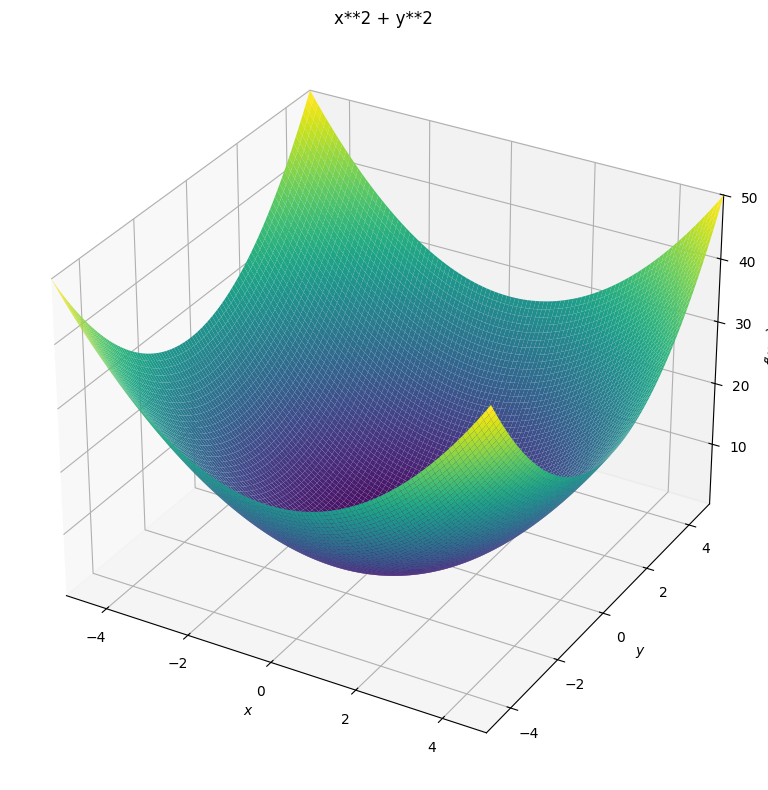

In [11]:

from sympy import symbols
from sympy.plotting import plot3d

x, y = symbols('x y')
plot3d(x**2 + y**2,
       (x, -5, 5), (y, -5, 5),
       title='x**2 + y**2',
       size=(8, 8))

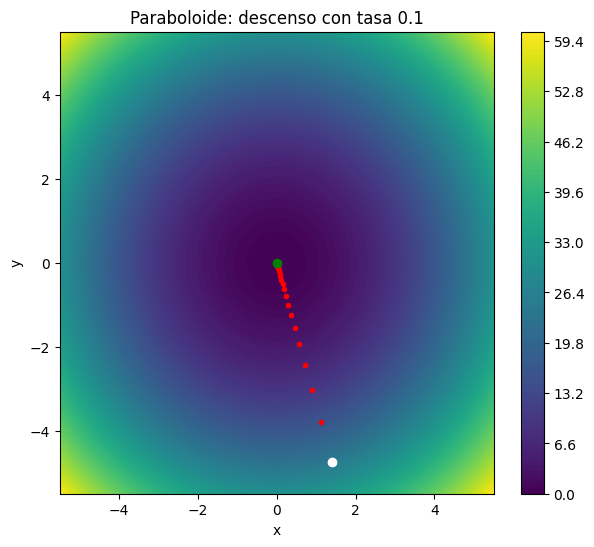

Punto inicial: [1.3943, -4.7499]
Solución     : [2e-05, -6.8e-05]  f = 4.99185066478449e-09


In [12]:
def dibuja_descenso(f, trayectoria, rango, titulo, resolucion=100):
    """Mapa de niveles de f con la trayectoria del descenso encima.

    El punto de partida se marca en blanco, los intermedios en rojo y el final en verde.
    """
    (x_min, x_max), (y_min, y_max) = rango

    X = np.linspace(x_min, x_max, resolucion)
    Y = np.linspace(y_min, y_max, resolucion)
    Z = np.zeros((resolucion, resolucion))
    for ix, vx in enumerate(X):
        for iy, vy in enumerate(Y):
            Z[iy, ix] = f([vx, vy])

    plt.figure(figsize=(7, 6))
    plt.contourf(X, Y, Z, resolucion)
    plt.colorbar()

    plt.plot(trayectoria[0][0], trayectoria[0][1], "o", c="white")      # Punto inicial
    for P in trayectoria[1:-1]:
        plt.plot(P[0], P[1], "o", c="red", markersize=3)                # Camino
    plt.plot(trayectoria[-1][0], trayectoria[-1][1], "o", c="green")    # Punto final

    plt.title(titulo)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


random.seed(42)   # Punto de partida aleatorio pero reproducible
P0 = [random.uniform(-5, 5), random.uniform(-5, 5)]
final, trayectoria = descenso_gradiente(f_paraboloide, df_paraboloide, P0,
                                        tasa=0.1, iteraciones=50)

dibuja_descenso(f_paraboloide, trayectoria, [(-5.5, 5.5), (-5.5, 5.5)],
                "Paraboloide: descenso con tasa 0.1")
print("Punto inicial:", [round(c, 4) for c in P0])
print("Solución     :", [round(c, 6) for c in final], " f =", f_paraboloide(final))

### Reducir la tasa de aprendizaje a medida que nos acercamos

La tasa de aprendizaje $\eta$ se ha mantenido fija, pero conviene revisar esa decisión: **sería más
efectivo reducirla conforme nos acercamos al mínimo**. La razón es que $\eta$ tiene que hacer dos
trabajos incompatibles. Al principio interesa un paso largo, para recorrer deprisa la distancia que
separa del valle. Al final interesa un paso corto, porque con uno largo se **salta por encima** del
mínimo una y otra vez, oscilando a su alrededor sin llegar a asentarse.

La forma más simple de conseguirlo es multiplicar la tasa por un factor algo menor que 1 en cada
iteración: $\eta_{k+1} = \gamma \cdot \eta_k$. Eso es lo que hace el parámetro `decaimiento`.

En el paraboloide se puede ver con precisión, porque el mínimo exacto se conoce el $(0,0)$ y basta
medir a qué distancia se queda el descenso. Conviene probarlo con tasas de distinta magnitud,
porque el efecto **no siempre es beneficioso**: si la tasa ya era pequeña, decaer solo frena la
convergencia.

In [14]:
# Distancia al mínimo real (0,0) tras 50 iteraciones, con y sin decaimiento
print(f"{'tasa':>6} | {'fija':>14} | {'decaimiento 0.95':>18} | {'veredicto':<28}")
print("-" * 78)

for tasa in (0.1, 0.5, 0.9, 0.95, 1.02):
    fija, _ = descenso_gradiente(f_paraboloide, df_paraboloide, [4.0, -3.5],
                                 tasa=tasa, iteraciones=50)
    decae, _ = descenso_gradiente(f_paraboloide, df_paraboloide, [4.0, -3.5],
                                  tasa=tasa, iteraciones=50, decaimiento=0.95)

    d_fija = math.hypot(*fija)
    d_decae = math.hypot(*decae)

    if d_fija > 1:
        veredicto = "la tasa fija DIVERGE"
    elif d_fija < 1e-12 and d_decae < 1e-12:
        veredicto = "ambas clavan el mínimo"
    elif d_decae < d_fija / 10:
        veredicto = "el decaimiento la asienta"
    elif d_fija < d_decae / 10:
        veredicto = "decaer solo frena"
    else:
        veredicto = "apenas hay diferencia"

    print(f"{tasa:>6} | {d_fija:>14.3e} | {d_decae:>18.3e} | {veredicto:<28}")

# Con una tasa demasiado grande el descenso fijo no converge, y el decaimiento lo rescata
divergente, _ = descenso_gradiente(f_paraboloide, df_paraboloide, [4.0, -3.5],
                                   tasa=1.02, iteraciones=50)
rescatado, _ = descenso_gradiente(f_paraboloide, df_paraboloide, [4.0, -3.5],
                                  tasa=1.02, iteraciones=50, decaimiento=0.95)
assert math.hypot(*divergente) > 1, "con tasa 1.02 el descenso fijo debería divergir"
assert math.hypot(*rescatado) < 1e-6, "el decaimiento debería rescatarlo"

print("\nCon tasa 0.1 la fija ya converge y decaer solo la frena. En 0.9 ambas llegan al mínimo,")
print("pero el decaimiento gana catorce órdenes de magnitud en precisión. A partir de 0.95 la tasa")
print("fija ya no se asienta, y con 1.02 diverge: ahí el decaimiento es lo que separa no encontrar")
print("nada de clavar el mínimo.")

  tasa |           fija |   decaimiento 0.95 | veredicto                   
------------------------------------------------------------------------------
   0.1 |      7.586e-05 |          1.057e-01 | decaer solo frena           
   0.5 |      0.000e+00 |          0.000e+00 | ambas clavan el mínimo      
   0.9 |      7.586e-05 |          2.715e-19 | el decaimiento la asienta   
  0.95 |      2.739e-02 |          2.881e-19 | el decaimiento la asienta   
  1.02 |      3.777e+01 |          1.163e-19 | la tasa fija DIVERGE        

Con tasa 0.1 la fija ya converge y decaer solo la frena. En 0.9 ambas llegan al mínimo,
pero el decaimiento gana catorce órdenes de magnitud en precisión. A partir de 0.95 la tasa
fija ya no se asienta, y con 1.02 diverge: ahí el decaimiento es lo que separa no encontrar
nada de clavar el mínimo.


## 3.2 El ejercicio propuesto: ¿te atreves a optimizar la función?

$$f(x,y)=\sin\left(\tfrac{1}{2}x^2 - \tfrac{1}{4}y^2 + 3\right) \cdot \cos\left(2x + 1 - e^y\right)$$

### Cálculo del gradiente

Es un producto de dos funciones compuestas. Llamando

$$u = \tfrac{1}{2}x^2 - \tfrac{1}{4}y^2 + 3 \qquad v = 2x + 1 - e^y$$

la función es $f = \sin(u)\cdot\cos(v)$, con derivadas parciales inmediatas:

$$\frac{\partial u}{\partial x} = x \qquad \frac{\partial u}{\partial y} = -\frac{y}{2} \qquad
\frac{\partial v}{\partial x} = 2 \qquad \frac{\partial v}{\partial y} = -e^{y}$$

Aplicando la regla del producto y la de la cadena:

$$\frac{\partial f}{\partial x} = \cos(u)\frac{\partial u}{\partial x}\cos(v) - \sin(u)\sin(v)\frac{\partial v}{\partial x} = x\cos(u)\cos(v) - 2\sin(u)\sin(v)$$

$$\frac{\partial f}{\partial y} = \cos(u)\frac{\partial u}{\partial y}\cos(v) - \sin(u)\sin(v)\frac{\partial v}{\partial y} = -\frac{y}{2}\cos(u)\cos(v) + e^{y}\sin(u)\sin(v)$$

### Una precaución sobre el dominio

El término $e^y$ hace que $v$ crezca exponencialmente con $y$, y con él la frecuencia con la que
oscila el coseno **respecto a $y$**: como $\partial v/\partial y = -e^{y}$, en $y=5$ el coseno
completa un ciclo entero cada $2\pi/e^{5} \approx 0{,}042$ unidades de $y$. La superficie deja de
ser algo por lo que «descender» y el gradiente se vuelve enorme e inútil.

En $x$, en cambio, la frecuencia no cambia: $\partial v/\partial x = 2$, así que el periodo vale
$\pi$ sea cual sea $y$. **El problema está, por tanto, solo en $y$**, porque $x$ entra en $v$ de
forma lineal y en $u$ de forma cuadrática, sin exponenciales. Por eso la búsqueda se acota a

$$x \in [-3, 3] \qquad y \in [-2, 2]$$

Acotar $x$ más de la cuenta tiene un efecto que conviene evitar: el mínimo se sitúa **en el borde**
del recuadro, y un punto de borde no es un mínimo de verdad, sino donde el recorte detiene la
búsqueda. Se reconoce porque su gradiente no llega a anularse. Con este dominio, en cambio, el
mínimo que se alcanza queda en el interior y con gradiente prácticamente nulo, como se comprueba
más abajo.

### Cota del valor óptimo

Como $f$ es el producto de un seno por un coseno, y ambos están acotados entre $-1$ y $1$, se cumple
que $-1 \le f(x,y) \le 1$ **para todo punto**. Cualquier valor que encontremos cercano a $-1$ es,
por tanto, prácticamente óptimo: es una referencia que permite juzgar el resultado sin conocer la
solución exacta.

In [15]:
# Definimos la funcion
f = lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) * math.cos(2*X[0] + 1 - math.exp(X[1]))


def df(X):
    """Gradiente analítico, deducido con la regla del producto y la de la cadena."""
    x, y = X
    u = 1/2 * x**2 - 1/4 * y**2 + 3      # du/dx = x  ;  du/dy = -y/2
    v = 2*x + 1 - math.exp(y)            # dv/dx = 2  ;  dv/dy = -e^y

    df_dx = x * math.cos(u) * math.cos(v) - 2 * math.sin(u) * math.sin(v)
    df_dy = -y/2 * math.cos(u) * math.cos(v) + math.exp(y) * math.sin(u) * math.sin(v)

    return [df_dx, df_dy]


# Dominio de búsqueda: y acotado por el e^y, x con algo más de margen (ver la nota anterior)
LIMITES = [(-3, 3), (-2, 2)]


def punto_al_azar():
    """Un punto uniforme dentro del dominio de búsqueda."""
    return [random.uniform(*LIMITES[0]), random.uniform(*LIMITES[1])]


# --- Verificación del gradiente contra derivadas numéricas -------------------------------------
random.seed(1)
peor_error = 0.0
for _ in range(5000):
    P = punto_al_azar()
    analitico, numerico = df(P), gradiente_numerico(f, P)
    for a, n in zip(analitico, numerico):
        peor_error = max(peor_error, abs(a - n) / max(1.0, abs(n)))

assert peor_error < 1e-5, f"el gradiente analítico no cuadra: error {peor_error}"
print("Verificado: el gradiente analítico coincide con las diferencias finitas en 5000")
print(f"puntos del dominio. Error relativo máximo: {peor_error:.2e}")

Verificado: el gradiente analítico coincide con las diferencias finitas en 5000
puntos del dominio. Error relativo máximo: 5.63e-10


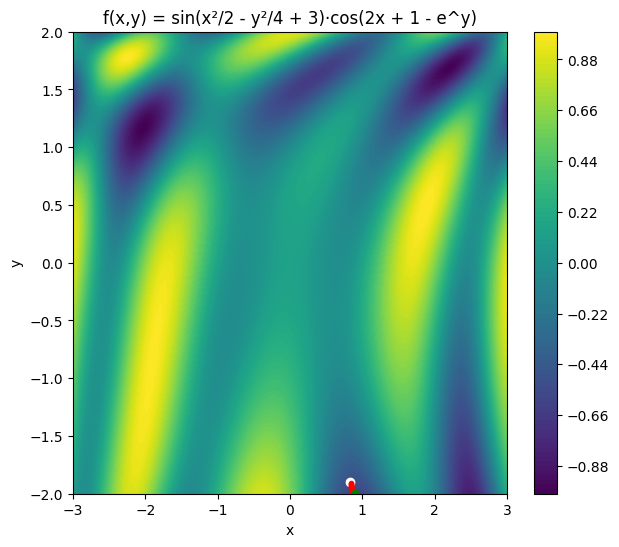

Punto inicial: [0.8366, -1.9]  f = -0.52138
Solución     : [0.9051, -2]  f = -0.596868


In [16]:
random.seed(42)
P0 = punto_al_azar()
final, trayectoria = descenso_gradiente(f, df, P0, tasa=0.01, iteraciones=500, limites=LIMITES)

dibuja_descenso(f, trayectoria, LIMITES,
                "f(x,y) = sin(x²/2 - y²/4 + 3)·cos(2x + 1 - e^y)")

print("Punto inicial:", [round(c, 4) for c in P0], " f =", round(f(P0), 6))
print("Solución     :", [round(c, 4) for c in final], " f =", round(f(final), 6))

### El descenso es local: hace falta más de un arranque

A diferencia del paraboloide, esta función tiene **muchos mínimos locales**. Un único descenso cae
al valle más cercano a su punto de partida, así que el resultado depende por completo de dónde se
empiece. La forma más simple de mitigarlo es repetir el descenso desde varios puntos aleatorios y
quedarse con el mejor, que es lo que hace la celda siguiente.

50 arranques aleatorios, tasa 0.01 y 500 iteraciones

   mejor valor        : -1.000000  en  (-2.0277, 1.1718)
   partiendo de       : (-1.1775, 1.5492)
   peor valor         : -0.000180
   arranques bajo -0.99 : 10 de 50

Verificado:
   el mínimo posible de un producto seno x coseno es -1, y se alcanza -1.000000
   la norma del gradiente ahí es 1.18e-08: es un punto crítico real
   y queda en el interior del dominio, no recortado contra un límite


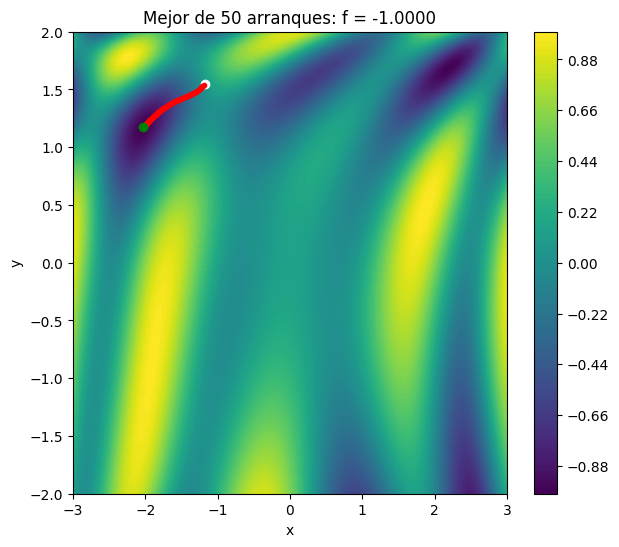

In [17]:
random.seed(2024)
ARRANQUES = 50

mejor_valor, mejor_punto, mejor_inicio, mejor_trayectoria = math.inf, None, None, None
valores = []

for _ in range(ARRANQUES):
    inicio = punto_al_azar()
    punto, trayectoria = descenso_gradiente(f, df, inicio, tasa=0.01,
                                            iteraciones=500, limites=LIMITES)
    valor = f(punto)
    valores.append(valor)

    if valor < mejor_valor:
        mejor_valor, mejor_punto = valor, punto
        mejor_inicio, mejor_trayectoria = inicio, trayectoria

print(f"{ARRANQUES} arranques aleatorios, tasa 0.01 y 500 iteraciones\n")
print(f"   mejor valor        : {mejor_valor:.6f}  en  "
      f"({mejor_punto[0]:.4f}, {mejor_punto[1]:.4f})")
print(f"   partiendo de       : ({mejor_inicio[0]:.4f}, {mejor_inicio[1]:.4f})")
print(f"   peor valor         : {max(valores):.6f}")
print(f"   arranques bajo -0.99 : {sum(1 for v in valores if v < -0.99)} de {ARRANQUES}")

# --- Verificación de que la solución es un mínimo de verdad ------------------------------------

# 1) Cota teórica: f es un producto de un seno por un coseno, luego -1 <= f <= 1 en todo punto
assert mejor_valor >= -1.0 - 1e-9, "ningún punto puede valer menos de -1"
assert mejor_valor < -0.999, "con 50 arranques debería alcanzarse el mínimo global"

# 2) El gradiente debe anularse ahí: es lo que distingue un mínimo real de un punto
#    donde simplemente se ha topado con el borde del dominio
norma_gradiente = math.hypot(*df(mejor_punto))
assert norma_gradiente < 1e-4, f"el gradiente no se anula: {norma_gradiente}"

# 3) Y el punto debe quedar en el interior, no pegado a los límites
for i, (minimo, maximo) in enumerate(LIMITES):
    assert minimo + 1e-6 < mejor_punto[i] < maximo - 1e-6, "la solución está en el borde"

print(f"\nVerificado:")
print(f"   el mínimo posible de un producto seno x coseno es -1, y se alcanza {mejor_valor:.6f}")
print(f"   la norma del gradiente ahí es {norma_gradiente:.2e}: es un punto crítico real")
print(f"   y queda en el interior del dominio, no recortado contra un límite")

dibuja_descenso(f, mejor_trayectoria, LIMITES,
                f"Mejor de {ARRANQUES} arranques: f = {mejor_valor:.4f}")

---
# 4. Conclusiones

| Técnica | Problema | Espacio de búsqueda | Complejidad | Garantía |
|---|---|---|---|---|
| Programación dinámica | Viaje por el río | Discreto, con subproblemas solapados | $O(n^3)$ | Óptimo exacto |
| Ramificación y poda | Asignación de tareas | Discreto, combinatorio | $O(n!)$ en el peor caso | Óptimo exacto |
| Descenso del gradiente | Minimizar $f(x,y)$ | Continuo y derivable | $O(\text{iteraciones})$ por arranque | Solo mínimo **local** |

**Lo que enseña comparar las tres:**

1. **La programación dinámica gana cuando los subproblemas se solapan.** El viaje por el río se
   resuelve en $O(n^3)$ frente a los $2^{n-2}$ caminos que explora la búsqueda exhaustiva, y todo el
   mérito está en el principio de optimalidad de Bellman: si el trayecto óptimo pasa por $k$, el
   tramo hasta $k$ es a su vez óptimo, y por eso puede reutilizarse.

2. **En ramificación y poda, la calidad de la cota lo es todo.** La poda solo es segura si la cota
   inferior nunca sobreestima. Una cota mal construida no hace que el algoritmo vaya más lento: le
   hace **devolver una solución equivocada**, porque descarta ramas que contenían el óptimo. En la
   matriz del enunciado, una estimación sobre las tareas equivocadas termina en coste 64 cuando el
   óptimo verificado es 61.

3. **El descenso del gradiente cambia garantía por generalidad.** Las dos primeras técnicas
   devuelven el óptimo exacto; ésta solo un mínimo local, y encima depende del punto de partida y de
   la tasa de aprendizaje. A cambio, es la única que sirve para un espacio continuo, donde
   enumerar soluciones no tiene ni sentido.

4. **Toda optimización necesita una referencia independiente.** Cada apartado se contrasta con algo
   verificable por otro camino: la búsqueda exhaustiva de todos los trayectos, las $n!$ asignaciones
   posibles, las derivadas por diferencias finitas y la cota teórica $f \ge -1$. Es lo que permite
   afirmar que los algoritmos son correctos, y no solo que producen un número.

---
# 5. Uso de inteligencia artificial

La inteligencia artificial fue utilizada como herramienta de apoyo en la redacción del presente trabajo, principalmente para mejorar la claridad de las ideas, corregir aspectos de redacción y evitar la repetición o redundancia de palabras y expresiones. El contenido, análisis y conclusiones presentados son responsabilidad del autor.